# 04 · Risco municipal: quem tende a não atingir a meta

Duas das perguntas estratégicas do desafio são sobre o município: quais apresentam maior risco educacional e como prever os que podem não atingir as metas futuras. O alvo natural é binário (`atingiu_meta_t`: o percentual de alfabetizados do ano ficou igual ou acima da meta pactuada), e a saída útil para o gestor é uma probabilidade de risco, ordenável.

O protocolo é o mesmo do modelo do aluno: treino e validação em 2024 com folds por município, teste em 2025 aberto uma vez, projeção para 2026. Mas aqui a EDA deixou um alerta: **a regra que define o alvo mudou entre os anos**. As metas de 2024 foram fixadas quase em cima do resultado de 2023, então atingir a meta em 2024 equivalia a "não cair"; as de 2025 exigem saltos maiores e crescentes. Um modelo que aprende diretamente o alvo binário em 2024 aprende a regra de 2024. Por isso este notebook compara duas formulações:

- **A. Classificador direto** do alvo binário;
- **B. Regressão do nível do indicador** (o percentual de alfabetizados), com o risco derivado da comparação entre o nível previsto e a meta do ano. A meta entra só no fim, e não no aprendizado.

A segunda é mais próxima de como o gestor pensa ("quanto o município deve alcançar, e isso basta para a meta?") e, como vai ficar claro, generaliza muito melhor para o ano seguinte.

In [1]:
import os
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir("..")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.base import clone
from sklearn.metrics import roc_auc_score

from src.preprocessing.features import grupos_municipio, preparar_xy, colunas
from src.preprocessing.pipeline import build_pipeline
from src.modeling.modelos import criar_modelos, criar_regressores
from src.modeling.train import buscar_hiperparametros, resumo_da_busca, salvar_modelo
from src.evaluation.metricas import avaliar_classificacao, avaliar_regressao, risco_de_nao_atingir, matriz_confusao, limiar_por_recall_negativos
from src.evaluation.validacao import validar_por_grupos, validar_regressao_por_grupos, resumir_folds
from src.preprocessing.splits import cv_por_municipio_regressao
from src.visualization.estilo import aplicar_estilo, salvar, fmt_pct, AZUL, LARANJA, CINZA, VERDE, VERMELHO, CORES_REGIAO
from src.visualization.rotulos import rotulo

aplicar_estilo()
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
SEED = 42

## 1. Base e variáveis

In [2]:
abt = pd.read_parquet("data/processed/abt_municipio.parquet")
grupos = grupos_municipio()
com_alvo = abt[abt["atingiu_meta_t"].notna()].copy()
treino = com_alvo[com_alvo["ano_alvo"] == 2024].copy()
teste = com_alvo[com_alvo["ano_alvo"] == 2025].copy()
projecao = abt[(abt["ano_alvo"] == 2026) & abt["meta_t"].notna()].copy()
print(f"treino 2024: {len(treino):,} municípios | teste 2025: {len(teste):,} | projeção 2026: {len(projecao):,}")
print(f"atingiram a meta: 2024 = {100 * treino['atingiu_meta_t'].astype(float).mean():.1f}% | 2025 = {100 * teste['atingiu_meta_t'].astype(float).mean():.1f}%")

x_tr, y_tr = preparar_xy(treino, grupos, "atingiu_meta_t")
x_te, y_te = preparar_xy(teste, grupos, "atingiu_meta_t")
g_tr, g_te = treino["id_municipio"].values, teste["id_municipio"].values
print(f"{len(colunas(grupos))} variáveis em {len(grupos)} blocos")

treino 2024: 5,425 municípios | teste 2025: 5,439 | projeção 2026: 5,477
atingiram a meta: 2024 = 53.0% | 2025 = 71.6%
39 variáveis em 4 blocos


## 2. Formulação A: classificador direto

Três famílias com busca aleatória de hiperparâmetros (15 combinações, 5 folds por município, critério AUC).

In [3]:
resultados_a = {}
for nome, (estimador, distribuicoes) in criar_modelos(n_jobs=1).items():
    busca = buscar_hiperparametros(build_pipeline(grupos, estimador), distribuicoes, x_tr, y_tr, g_tr, n_iter=15, n_splits=5, n_jobs=-1)
    tabela = resumo_da_busca(busca)
    proba_te = busca.best_estimator_.predict_proba(x_te)[:, 1]
    resultados_a[nome] = {
        "auc_validacao_2024": busca.best_score_,
        "auc_treino_2024": tabela.loc[0, "mean_train_score"],
        "auc_teste_2025": roc_auc_score(y_te, proba_te),
        "melhores": busca.best_params_,
        "estimador": busca.best_estimator_,
    }
tab_a = pd.DataFrame({k: {m: v[m] for m in ("auc_treino_2024", "auc_validacao_2024", "auc_teste_2025")} for k, v in resultados_a.items()}).T.astype(float)
tab_a.round(3)

,auc_treino_2024,auc_validacao_2024,auc_teste_2025
logistica,0.821,0.810,0.753
random_forest,0.905,0.806,0.627
lightgbm,0.909,0.812,0.598


O resultado expõe o problema: AUC em torno de 0,81 na validação de 2024 para as três famílias e uma queda forte no teste de 2025 para as árvores (0,60 a 0,63). A regressão logística, mais rígida, cai menos (0,75), justamente porque não consegue memorizar as interações específicas de 2024. Não é overfitting no sentido clássico, é **deriva na definição do alvo**. A verificação mais simples confirma: o salto necessário para a meta, que em 2025 é a variável mais preditiva sozinha, em 2024 não tinha relação nenhuma com o alvo.

In [4]:
def auc_simples(df, coluna, sinal=1):
    d = df.dropna(subset=[coluna])
    return roc_auc_score(d["atingiu_meta_t"].astype(int), sinal * d[coluna])

checagem = pd.DataFrame({
    "AUC em 2024": [auc_simples(treino, "salto_necessario", -1), auc_simples(treino, "indicador_t1"), auc_simples(treino, "distorcao_ai_pct", -1), auc_simples(treino, "ideb_ultimo")],
    "AUC em 2025": [auc_simples(teste, "salto_necessario", -1), auc_simples(teste, "indicador_t1"), auc_simples(teste, "distorcao_ai_pct", -1), auc_simples(teste, "ideb_ultimo")],
}, index=["salto necessário (menor = melhor)", rotulo("indicador_t1"), "distorção idade-série (menor = melhor)", rotulo("ideb_ultimo")]).round(3)
checagem

,AUC em 2024,AUC em 2025
salto necessário (menor = melhor),0.489,0.744
% alfabetizados no ano anterior,0.486,0.646
distorção idade-série (menor = melhor),0.619,0.551
IDEB anos iniciais (última edição),0.605,0.552


Em 2024, "atingir a meta" era quase um sorteio em relação ao nível anterior (AUC 0,49), porque a meta acompanhava o resultado de 2023 de perto: quem atingiu foi quem não caiu, e a EDA mostrou regressão à média forte. Em 2025 o alvo passou a depender do salto. O classificador direto aprendeu o mundo de 2024 e não tinha como saber que a regra mudaria.

**Decisão:** o classificador direto não é o modelo entregue. Fica registrado como comparação e como lição sobre alvos que dependem de regras administrativas.

## 3. Formulação B: regressão do nível e risco derivado

O nível do indicador não depende da regra da meta, e a EDA mostrou que ele é bem previsto pelo histórico, pelo IDEB e pelo fluxo escolar. O risco de não atingir a meta é derivado depois: `P(nível real < meta) = P(resíduo < meta − nível previsto)`, com a distribuição empírica dos resíduos da validação (fora da amostra). É a mesma lógica de um intervalo de previsão.

Mesmas famílias, na versão de regressão (Ridge, Random Forest, LightGBM), com `GroupKFold` por município e o erro absoluto médio como critério.

In [5]:
y_tr_nivel = treino["indicador_t"].astype(float)
y_te_nivel = teste["indicador_t"].astype(float)
resultados_b = {}
for nome, (estimador, distribuicoes) in criar_regressores(n_jobs=1).items():
    busca = buscar_hiperparametros(build_pipeline(grupos, estimador), distribuicoes, x_tr, y_tr_nivel, g_tr, n_iter=15, n_splits=5, n_jobs=-1, scoring="neg_mean_absolute_error", regressao=True)
    folds, oof = validar_regressao_por_grupos(busca.best_estimator_, x_tr, y_tr_nivel, g_tr, n_splits=5)
    residuos = y_tr_nivel.values - oof
    risco_val = risco_de_nao_atingir(oof, treino["meta_t"].values, residuos)
    pred_te = busca.best_estimator_.predict(x_te)
    risco_te = risco_de_nao_atingir(pred_te, teste["meta_t"].values, residuos)
    r = resumir_folds(folds, metricas=("mae", "r2", "spearman"))
    resultados_b[nome] = {
        "mae_treino_2024": r.loc["treino", ("media", "mae")],
        "mae_validacao_2024": r.loc["validacao", ("media", "mae")],
        "r2_validacao_2024": r.loc["validacao", ("media", "r2")],
        "auc_risco_validacao_2024": roc_auc_score(y_tr, 1 - risco_val),
        "mae_teste_2025": avaliar_regressao(y_te_nivel, pred_te)["mae"],
        "vies_teste_2025": avaliar_regressao(y_te_nivel, pred_te)["vies"],
        "spearman_teste_2025": avaliar_regressao(y_te_nivel, pred_te)["spearman"],
        "auc_risco_teste_2025": roc_auc_score(y_te, 1 - risco_te),
        "melhores": busca.best_params_,
        "estimador": busca.best_estimator_,
        "residuos": residuos,
        "oof": oof,
    }
tab_b = pd.DataFrame({k: {m: v[m] for m in v if m not in ("melhores", "estimador", "residuos", "oof")} for k, v in resultados_b.items()}).T.astype(float)
tab_b.round(3)

,mae_treino_2024,mae_validacao_2024,r2_validacao_2024,auc_risco_validacao_2024,mae_teste_2025,vies_teste_2025,spearman_teste_2025,auc_risco_teste_2025
ridge,8.390,8.537,0.648,0.797,11.535,-8.147,0.710,0.763
random_forest,7.556,8.803,0.627,0.783,11.691,-7.553,0.672,0.760
lightgbm,7.358,8.486,0.646,0.797,11.377,-7.323,0.693,0.772


A regressão do nível muda o quadro. O AUC do risco derivado em 2025 fica em 0,77 para o LightGBM (0,76 para Ridge e Random Forest), contra 0,60 do melhor classificador direto, mesmo com o modelo tendo sido treinado só com 2024. O viés negativo no teste (o modelo subestima o nível de 2025 em cerca de 8 pontos) é o salto nacional que nenhum modelo treinado em 2024 poderia prever, e mesmo assim o **ranking** se mantém (Spearman próximo de 0,7). É isso que o gestor precisa: saber quem está mais longe da meta, em ordem.

In [6]:
melhor_b = tab_b["auc_risco_teste_2025"].idxmax()
print("melhor regressor:", melhor_b)
comparacao = pd.DataFrame({
    "classificador direto (melhor)": {"AUC validação 2024": tab_a["auc_validacao_2024"].max(), "AUC teste 2025": tab_a.loc[tab_a["auc_validacao_2024"].idxmax(), "auc_teste_2025"]},
    "regra simples: salto necessário": {"AUC validação 2024": auc_simples(treino, "salto_necessario", -1), "AUC teste 2025": auc_simples(teste, "salto_necessario", -1)},
    f"regressão do nível + meta ({melhor_b})": {"AUC validação 2024": tab_b.loc[melhor_b, "auc_risco_validacao_2024"], "AUC teste 2025": tab_b.loc[melhor_b, "auc_risco_teste_2025"]},
}).T.round(3)
comparacao

melhor regressor: lightgbm


,AUC validação 2024,AUC teste 2025
classificador direto (melhor),0.812,0.598
regra simples: salto necessário,0.489,0.744
regressão do nível + meta (lightgbm),0.797,0.772


A tabela resume a decisão. A regra simples "quanto falta para a meta" já é forte em 2025, e a regressão do nível a supera porque incorpora o que o histórico não diz: fluxo escolar, IDEB, contexto. E ela é a única formulação que funciona nos dois anos.

## 4. Diagnóstico do modelo escolhido

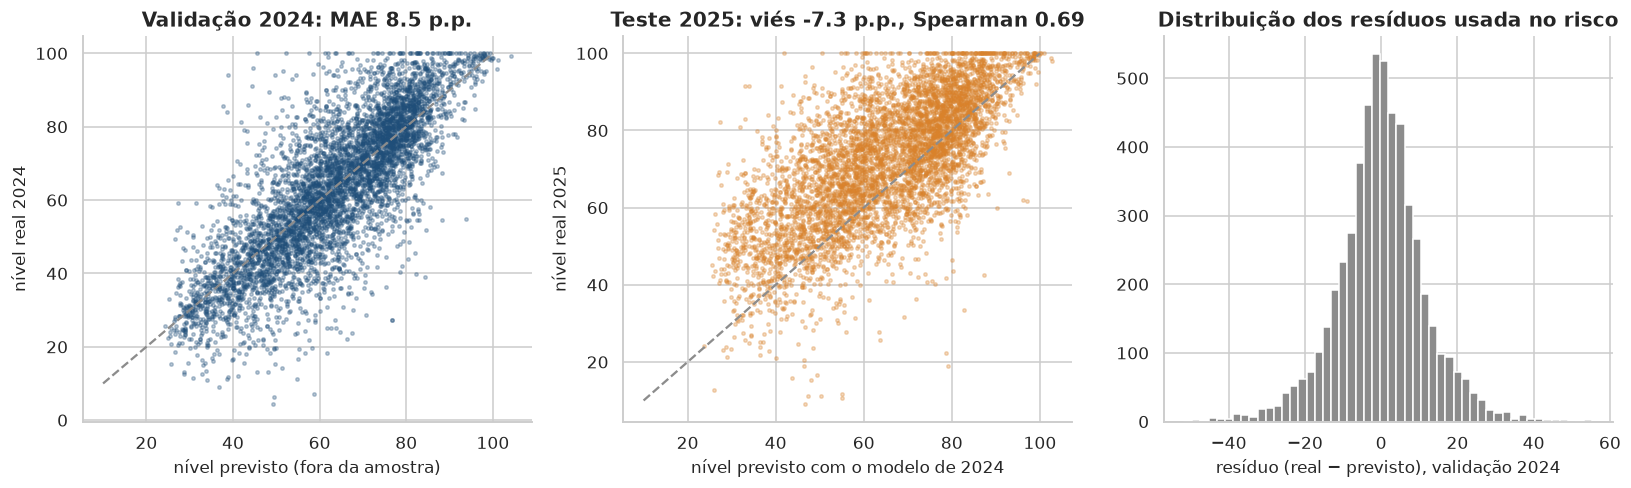

In [7]:
modelo_b = resultados_b[melhor_b]["estimador"]
oof_b = resultados_b[melhor_b]["oof"]
residuos_b = resultados_b[melhor_b]["residuos"]
pred_te_b = modelo_b.predict(x_te)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
axes[0].scatter(oof_b, y_tr_nivel, s=5, alpha=0.3, color=AZUL)
axes[0].plot([10, 100], [10, 100], color=CINZA, ls="--")
axes[0].set_xlabel("nível previsto (fora da amostra)")
axes[0].set_ylabel("nível real 2024")
axes[0].set_title(f"Validação 2024: MAE {tab_b.loc[melhor_b, 'mae_validacao_2024']:.1f} p.p.")
axes[1].scatter(pred_te_b, y_te_nivel, s=5, alpha=0.3, color=LARANJA)
axes[1].plot([10, 100], [10, 100], color=CINZA, ls="--")
axes[1].set_xlabel("nível previsto com o modelo de 2024")
axes[1].set_ylabel("nível real 2025")
axes[1].set_title(f"Teste 2025: viés {tab_b.loc[melhor_b, 'vies_teste_2025']:.1f} p.p., Spearman {tab_b.loc[melhor_b, 'spearman_teste_2025']:.2f}")
axes[2].hist(residuos_b, bins=50, color=CINZA)
axes[2].set_xlabel("resíduo (real − previsto), validação 2024")
axes[2].set_title("Distribuição dos resíduos usada no risco")
salvar(fig, "04_regressao_nivel")
plt.show()

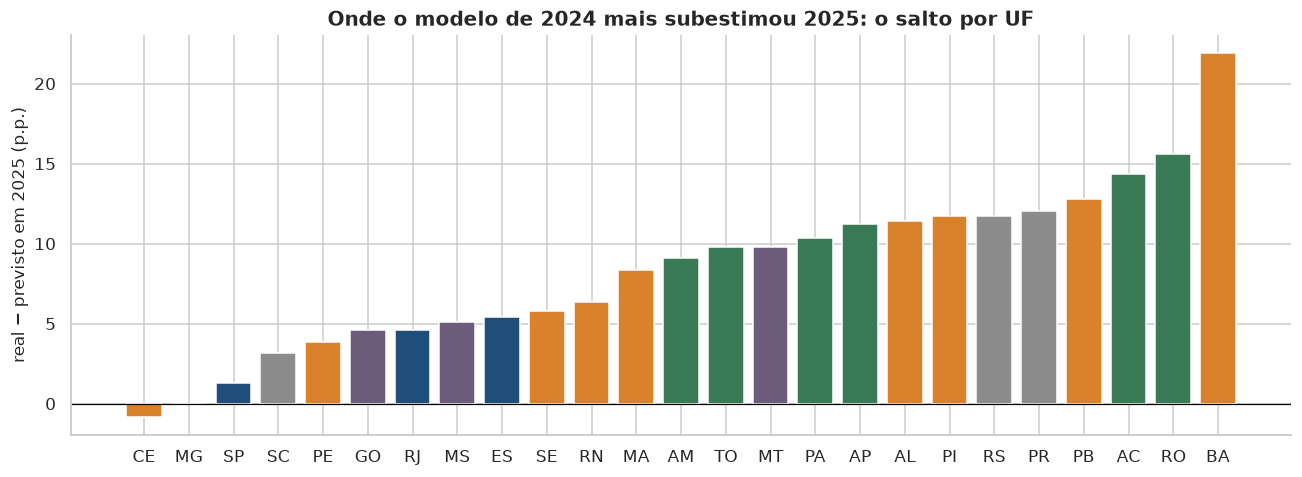

In [8]:
# residuo de 2025 por UF: onde a deriva foi maior
erro_uf = teste.assign(residuo=y_te_nivel.values - pred_te_b).groupby("sigla_uf")["residuo"].agg(["mean", "median", "count"]).sort_values("mean")
fig, ax = plt.subplots(figsize=(12, 4.5))
cores = [CORES_REGIAO[r] for r in teste.drop_duplicates("sigla_uf").set_index("sigla_uf").loc[erro_uf.index, "nome_regiao"]]
ax.bar(erro_uf.index, erro_uf["mean"], color=cores)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("real − previsto em 2025 (p.p.)")
ax.set_title("Onde o modelo de 2024 mais subestimou 2025: o salto por UF")
salvar(fig, "04_residuo_por_uf")
plt.show()

O erro em 2025 é quase todo um deslocamento positivo (o país subiu mais do que o histórico sugeria), concentrado em alguns estados (Bahia, Acre, Alagoas, Tocantins) que saltaram mais de 15 pontos. O modelo não erra a ordem; erra o nível de um ano atípico. A conclusão operacional é que o modelo precisa ser reajustado a cada ciclo com o ano mais recente, e é isso que o próximo bloco faz para a projeção.

## 5. Ponto de operação e matriz de confusão no teste

Para transformar o risco em lista de ação, a operação define um recall mínimo: encontrar pelo menos 70% dos municípios que de fato não atingem a meta. O limiar é escolhido na validação de 2024 e aplicado em 2025.

In [9]:
risco_val = risco_de_nao_atingir(oof_b, treino["meta_t"].values, residuos_b)
risco_te = risco_de_nao_atingir(pred_te_b, teste["meta_t"].values, residuos_b)
p_val, p_te = 1 - risco_val, 1 - risco_te  # probabilidade de atingir
limiar_op = limiar_por_recall_negativos(y_tr.values, p_val, recall_minimo=0.70)
print(f"limiar sobre a probabilidade de atingir: {limiar_op:.2f} (risco >= {1 - limiar_op:.2f} entra na lista)")
metricas = pd.DataFrame({
    "validação 2024": avaliar_classificacao(y_tr.values, p_val, limiar_op),
    "teste 2025": avaliar_classificacao(y_te.values, p_te, limiar_op),
}).T.round(3)
metricas

limiar sobre a probabilidade de atingir: 0.53 (risco >= 0.47 entra na lista)


,auc_roc,auc_pr,acuracia,precisao,recall,f1,precisao_negativos,recall_negativos,limiar,taxa_base
validação 2024,0.797,0.806,0.723,0.739,0.740,0.739,0.706,0.704,0.53,0.530
teste 2025,0.772,0.888,0.652,0.887,0.589,0.708,0.439,0.811,0.53,0.716


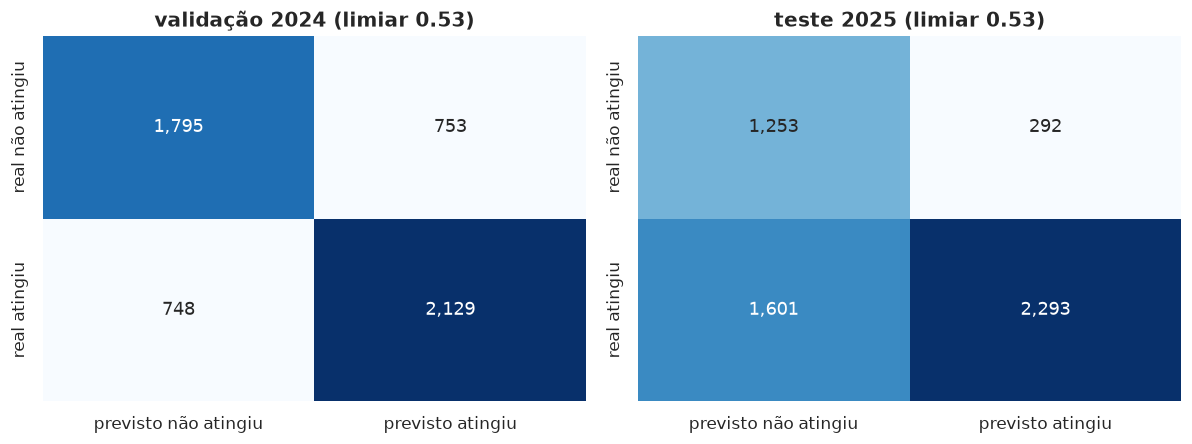

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, (nome, y, p) in zip(axes, [("validação 2024", y_tr.values, p_val), ("teste 2025", y_te.values, p_te)]):
    mc = matriz_confusao(y, p, limiar_op, rotulos=("não atingiu", "atingiu"))
    sns.heatmap(mc, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(f"{nome} (limiar {limiar_op:.2f})")
salvar(fig, "04_matriz_confusao")
plt.show()

Em 2025 o recall da classe "não atingiu" cai em relação a 2024 pelo mesmo motivo do viés: o modelo de 2024 é pessimista para 2025, então mais municípios entram na lista de risco do que o necessário (a precisão dos negativos cai e o recall dos negativos sobe). Numa lista de triagem isso é o erro menos custoso, mas reforça o reajuste anual.

## 6. Projeção para 2026

Para projetar, o modelo é reajustado com o **retrato mais recente**: as linhas com alvo em 2025 (variáveis conhecidas até o início de 2025, resultado de 2025). Testei também o ajuste com 2024 e 2025 juntos; os dois rankings são muito parecidos (correlação de 0,88 entre os riscos), mas o ano de 2024 carrega choques localizados que já não valem, como a queda de 20 pontos do Rio Grande do Sul (enchentes de 2024, com recuperação parcial em 2025), e o modelo combinado penalizava os municípios gaúchos além do que o dado de 2025 justifica. Os resíduos vêm de uma validação por grupos na base de 2025, e o risco de cada município para a meta de 2026 é derivado da mesma forma. As variáveis de 2026 são as últimas disponíveis (Censo Escolar 2025, rendimento 2024, IDEB 2025, indicador 2025), como registrado na ABT.

In [11]:
base_final = com_alvo[com_alvo["ano_alvo"] == 2025].copy()
x_fin, _ = preparar_xy(base_final, grupos, "atingiu_meta_t")
y_fin = base_final["indicador_t"].astype(float)
g_fin = base_final["id_municipio"].values
estimador_final = clone(criar_regressores(n_jobs=-1)[melhor_b][0]).set_params(**{k.replace("modelo__", ""): v for k, v in resultados_b[melhor_b]["melhores"].items()})
modelo_final = build_pipeline(grupos, estimador_final)
folds_fin, oof_fin = validar_regressao_por_grupos(modelo_final, x_fin, y_fin, g_fin, n_splits=5)
residuos_fin = y_fin.values - oof_fin
print("validação por grupos na base de 2025:")
display(resumir_folds(folds_fin, metricas=("mae", "r2", "spearman")))
modelo_final.fit(x_fin, y_fin)

x_proj, _ = preparar_xy(projecao.assign(atingiu_meta_t=0), grupos, "atingiu_meta_t")
projecao["nivel_previsto_2026"] = modelo_final.predict(x_proj)
projecao["risco_2026"] = risco_de_nao_atingir(projecao["nivel_previsto_2026"].values, projecao["meta_t"].values, residuos_fin)
projecao["folga_prevista_pp"] = projecao["nivel_previsto_2026"] - projecao["meta_t"]
print(f"municípios com risco acima de 50%: {(projecao['risco_2026'] >= 0.5).sum():,} de {len(projecao):,} ({100 * (projecao['risco_2026'] >= 0.5).mean():.0f}%)")

validação por grupos na base de 2025:


media                   desvio                 
              mae      r2 spearman     mae      r2 spearman
conjunto                                                   
treino     6.5422  0.7165   0.8451  0.0508  0.0048   0.0026
validacao  7.5935  0.6096   0.7802  0.2353  0.0310   0.0175

municípios com risco acima de 50%: 914 de 5,477 (17%)


In [12]:
ranking = projecao[["id_municipio", "nome_municipio", "sigla_uf", "nome_regiao", "indicador_t1", "meta_t", "salto_necessario", "nivel_previsto_2026", "folga_prevista_pp", "risco_2026", "distorcao_ai_pct", "ideb_ultimo", "inse_medio", "populacao"]].copy()
ranking = ranking.rename(columns={"indicador_t1": "indicador_2025", "meta_t": "meta_2026", "salto_necessario": "salto_necessario_pp"})
ranking = ranking.sort_values("risco_2026", ascending=False).reset_index(drop=True)
ranking["posicao"] = np.arange(1, len(ranking) + 1)
Path("reports").mkdir(exist_ok=True)
ranking.round(2).to_csv("reports/municipios_risco_2026.csv", index=False)
ranking.head(20).round(2)

,id_municipio,nome_municipio,sigla_uf,nome_regiao,indicador_2025,meta_2026,salto_necessario_pp,nivel_previsto_2026,folga_prevista_pp,risco_2026,distorcao_ai_pct,ideb_ultimo,inse_medio,populacao,posicao
0,4310553,Itacurubi,RS,Sul,20.59,80.00,59.41,44.38,-35.62,1.00,6.1,6.1,5.07,2995.0,1
1,4301909,Barra do Ribeiro,RS,Sul,37.81,73.90,36.09,45.78,-28.12,1.00,9.5,5.4,5.31,12225.0,2
2,4319364,São Pedro das Missões,RS,Sul,NaN,80.00,NaN,52.34,-27.66,1.00,4.5,NaN,5.04,1757.0,3
3,4300638,Amaral Ferrador,RS,Sul,24.62,74.91,50.29,48.18,-26.73,1.00,7.4,5.3,4.88,5310.0,4
4,4307401,Esmeralda,RS,Sul,35.56,80.00,44.44,53.91,-26.09,0.99,5.2,5.9,5.33,3195.0,5
5,4314209,Pedro Osório,RS,Sul,36.84,73.44,36.60,47.52,-25.92,0.99,14.2,5.6,5.12,7484.0,6
6,4305124,Cerrito,RS,Sul,53.70,77.28,23.58,51.69,-25.59,0.99,8.5,5.4,5.09,5808.0,7
7,4315602,Rio Grande,RS,Sul,35.73,66.59,30.86,41.18,-25.41,0.99,15.7,5.5,5.29,191900.0,8
8,4314100,Passo Fundo,RS,Sul,39.33,68.81,29.48,45.44,-23.37,0.99,11.8,5.7,5.47,206215.0,9
9,4318309,São Gabriel,RS,Sul,44.20,70.12,25.92,46.81,-23.31,0.99,14.8,5.6,5.36,58487.0,10


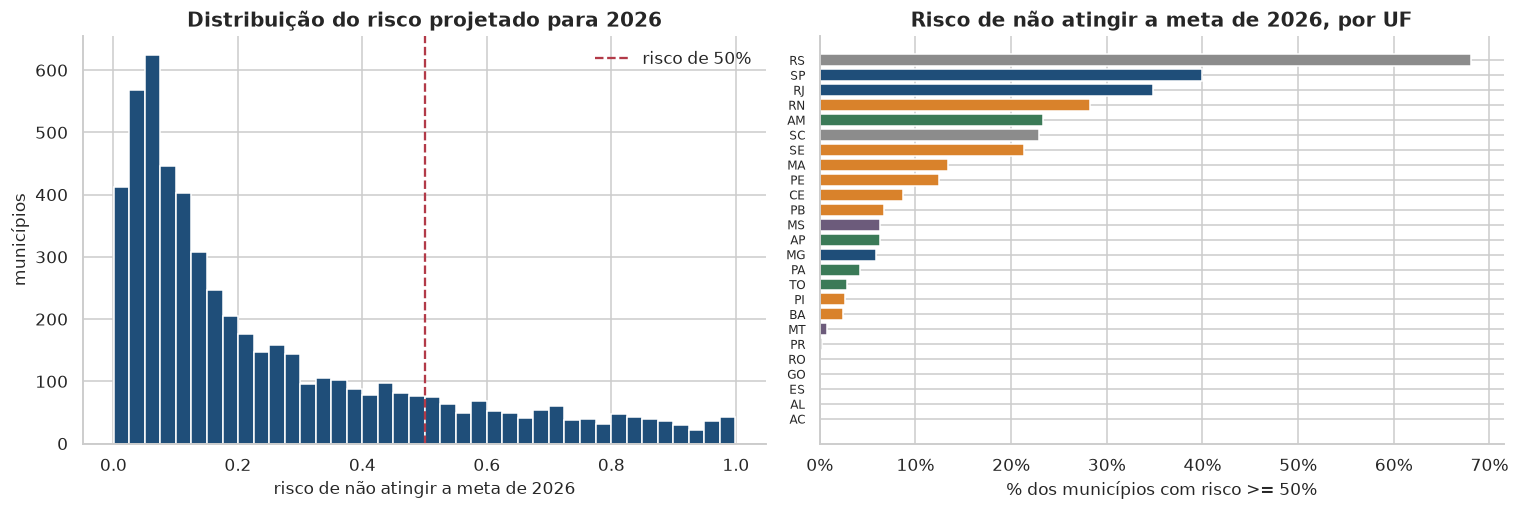

,risco_medio,em_risco,municipios
sigla_uf,,,
RS,0.636,0.681,476
SP,0.454,0.399,629
RJ,0.408,0.348,92
RN,0.323,0.282,163
AM,0.340,0.233,60
SC,0.334,0.229,284
SE,0.276,0.213,75
MA,0.242,0.134,217
PE,0.238,0.125,184


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].hist(projecao["risco_2026"], bins=40, color=AZUL)
axes[0].axvline(0.5, color=VERMELHO, ls="--", label="risco de 50%")
axes[0].set_xlabel("risco de não atingir a meta de 2026")
axes[0].set_ylabel("municípios")
axes[0].set_title("Distribuição do risco projetado para 2026")
axes[0].legend()

por_uf = projecao.groupby("sigla_uf").agg(risco_medio=("risco_2026", "mean"), em_risco=("risco_2026", lambda s: (s >= 0.5).mean()), municipios=("id_municipio", "size")).sort_values("em_risco")
cores = [CORES_REGIAO[r] for r in projecao.drop_duplicates("sigla_uf").set_index("sigla_uf").loc[por_uf.index, "nome_regiao"]]
axes[1].barh(por_uf.index, 100 * por_uf["em_risco"], color=cores)
axes[1].set_xlabel("% dos municípios com risco >= 50%")
axes[1].set_title("Risco de não atingir a meta de 2026, por UF")
axes[1].tick_params(axis="y", labelsize=8)
fmt_pct(axes[1])
salvar(fig, "04_risco_2026")
plt.show()
por_uf.round(3).sort_values("em_risco", ascending=False).head(10)

A projeção diz onde concentrar esforço em 2026. Os estados com maior fatia de municípios em risco são os que combinam nível atual distante de metas que sobem depressa; municípios com folga negativa de mais de 10 pontos têm risco próximo de 1. A lista completa está em `reports/municipios_risco_2026.csv`, com as variáveis que explicam a posição de cada município (histórico, distorção, IDEB, INSE), para que a conversa com o gestor não pare no número.

O caso do Rio Grande do Sul merece leitura própria. As metas do estado foram ancoradas no resultado de 2023 (73% em média), o indicador caiu para 52% em 2024 e voltou a 64% em 2025; a meta de 2026 (74% em média) exige que o estado supere o nível de antes das enchentes. O modelo coloca a maioria dos municípios gaúchos em risco porque a régua está longe, não porque as redes sejam frágeis; é um caso em que a resposta de política pode ser repactuar a trajetória, e o modelo serve para dimensionar isso.

## 7. Persistência e registro

In [14]:
metadados = {
    "alvo_operacional": "risco de não atingir a meta do ano (derivado do nível previsto)",
    "alvo_modelado": "indicador_t (percentual de alfabetizados da rede municipal)",
    "formulacao": "regressão do nível + comparação com a meta via distribuição empírica dos resíduos",
    "por_que_nao_classificador_direto": "a regra da meta mudou entre 2024 e 2025; o classificador direto cai de 0,80 para 0,63 de AUC no teste temporal",
    "modelo": melhor_b,
    "hiperparametros": {k.replace("modelo__", ""): v for k, v in resultados_b[melhor_b]["melhores"].items()},
    "treino_final": "linhas com alvo em 2025 (retrato mais recente); resíduos de GroupKFold por município",
    "backtest_2024_para_2025": {k: float(tab_b.loc[melhor_b, k]) for k in tab_b.columns},
    "classificador_direto": {k: {m: float(v[m]) for m in ("auc_validacao_2024", "auc_teste_2025")} for k, v in resultados_a.items()},
    "limiar_operacao_prob_atingir": float(limiar_op),
    "metricas_operacao": metricas.to_dict(orient="index"),
    "projecao_2026": {"municipios": int(len(projecao)), "em_risco_50": int((projecao["risco_2026"] >= 0.5).sum())},
    "features": grupos,
}
salvar_modelo(modelo_final, "modelo_municipio", metadados)
pd.DataFrame({"id_municipio": base_final["id_municipio"].values, "ano_alvo": base_final["ano_alvo"].values, "nivel_oof": oof_fin, "residuo": residuos_fin}).to_parquet("models/modelo_municipio_oof.parquet", index=False)
teste.assign(nivel_previsto=pred_te_b, risco=risco_te)[["id_municipio", "sigla_uf", "indicador_t", "meta_t", "atingiu_meta_t", "nivel_previsto", "risco"]].to_parquet("models/modelo_municipio_backtest_2025.parquet", index=False)
print("modelo e artefatos salvos em models/")

modelo e artefatos salvos em models/


## 8. O que fica registrado

- **Alvo binário dependente de regra administrativa é traiçoeiro**: o classificador direto aprendeu a regra de 2024 e falhou em 2025. A regressão do nível, com a meta aplicada depois, é a formulação robusta.
- **Backtest temporal** (2024 → 2025): AUC do risco próximo de 0,77, acima da regra simples e muito acima do classificador; viés de nível de −8 p.p. explicado pelo salto nacional de 2025.
- **Projeção 2026** com o modelo reajustado no retrato mais recente (2025), risco por município em `reports/municipios_risco_2026.csv`; o Rio Grande do Sul aparece no topo porque as metas foram ancoradas antes da queda de 2024.
- **Operação**: limiar por recall mínimo de 70% dos municípios que não atingem; reajuste anual obrigatório.
- **Limitação**: o modelo não prevê choques de política (como o salto de 2025); prevê a trajetória dado o contexto.